In [1]:
import torch  
from torchvision import datasets, transforms 

In [2]:
data_dir = "/kaggle/input/fruit-recognition/train/train"

In [3]:
all_dataset = datasets.ImageFolder(data_dir)

In [4]:
all_dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [5]:
num_classes = len(all_dataset.classes)
num_classes

33

In [6]:
from torchvision import transforms

IMG_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [7]:
len(all_dataset)

16854

In [8]:
data_train, data_test = torch.utils.data.random_split(all_dataset,[0.8, 0.2])

In [9]:
print(len(data_train), len(data_test), len(data_train) + len(data_test))

13484 3370 16854


In [10]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]
        new_img = self.transformer(img)
        return new_img, y

In [11]:
train_data = TransformDataset(data_train,train_transform)
test_data = TransformDataset(data_test,test_transform)
print(len(train_data), len(test_data))

13484 3370


In [12]:
train_loader = DataLoader(train_data, batch_size=64)
test_loader = DataLoader(test_data, batch_size=64)

In [13]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 

torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size([64, 3, 64, 64])
torch.Size([64])
torch.Size

(64, 64, 3)


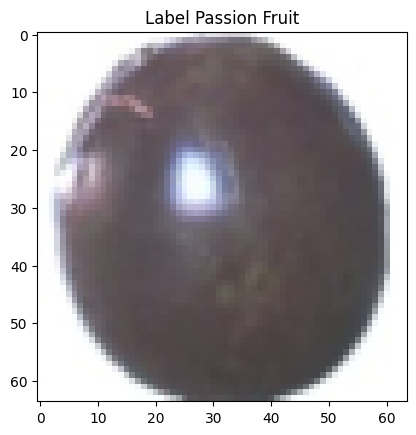

(64, 64, 3)


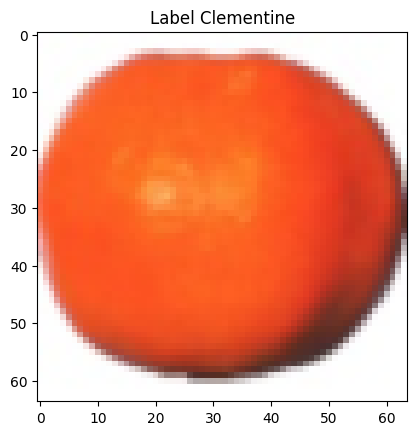

(64, 64, 3)


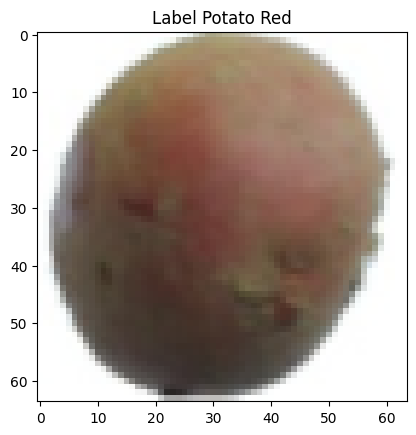

In [14]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = all_dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

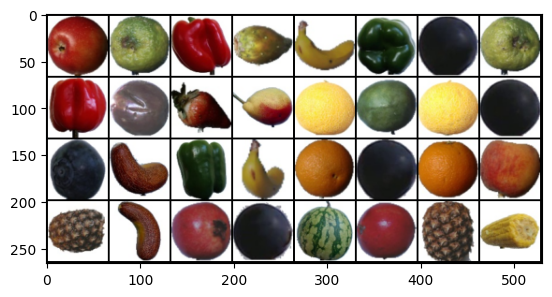

In [15]:
from torchvision.utils import make_grid
loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)
batch, labels = next(iter(loader))
grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор
plt.imshow(grid)

In [16]:
batch.shape

torch.Size([32, 3, 64, 64])

In [17]:
img, label = train_data[0]
img.shape

torch.Size([3, 64, 64])

In [18]:

for img,idx in test_loader:
    break

img.shape

torch.Size([64, 3, 64, 64])

In [19]:

device = 'cuda'
16*28*28

12544

In [20]:

import torch
import torch.nn as nn

# num_classes = len(train_dataset.classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = nn.Sequential(
    nn.Conv2d(3, 8, kernel_size=3, padding=1),  # filter 3x3
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),      # 2x2, stride 2

    nn.Conv2d(8, 16, kernel_size=3, padding=1), # filter 3x3
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),# filter 3x3
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.AdaptiveAvgPool2d((4,4)),
    nn.Flatten(),
    nn.Linear(32*4*4, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)                 #  33 класи
).to(device)

In [21]:
for imgs, labels in train_loader:
    break
imgs.shape

torch.Size([64, 3, 64, 64])

In [22]:

import torch
from tqdm import tqdm

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for batch_idx, (imgs, labels) in enumerate(tqdm(train_loader, leave=False)):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")

    print(f"===== Epoch {epoch+1} finished. Avg train loss: {running_loss/len(train_loader):.4f}")

  0%|          | 1/211 [00:01<06:30,  1.86s/it]

Epoch 1/10, Batch 0/211, Loss: 3.4972


 10%|▉         | 21/211 [00:08<01:00,  3.13it/s]

Epoch 1/10, Batch 20/211, Loss: 3.4646


 19%|█▉        | 41/211 [00:14<00:55,  3.08it/s]

...

 86%|████████▋ | 182/211 [00:23<00:03,  7.95it/s]

Epoch 10/10, Batch 180/211, Loss: 0.0004


 96%|█████████▌| 202/211 [00:26<00:01,  8.31it/s]

Epoch 10/10, Batch 200/211, Loss: 0.0008


===== Epoch 10 finished. Avg train loss: 0.0025


In [23]:

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm.shape)  # має бути (33, 33)
print(cm)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision (macro):", precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Recall (macro):", recall_score(y_true, y_pred, average="macro", zero_division=0))
print("F1 (macro):", f1_score(y_true, y_pred, average="macro", zero_division=0))

print("\nReport:\n", classification_report(
    y_true, y_pred, zero_division=0
))

Confusion matrix shape: (33, 33)
[[ 75   0   0 ...   0   0   0]
 [  0 101   0 ...   0   0   0]
 [  0   0  94 ...   0   0   0]
 ...
 [  0   0   0 ... 111   0   0]
 [  0   0   0 ...   0 133   0]
 [  0   0   0 ...   0   0  93]]
Accuracy: 0.9997032640949555
Precision (macro): 0.9996939087848179
Recall (macro): 0.999621212121212
F1 (macro): 0.9996555924149068

Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00       101
           2       1.00      1.00      1.00        94
           3       1.00      1.00      1.00        93
           4       0.99      1.00      0.99        98
           5       1.00      1.00      1.00        78
           6       1.00      1.00      1.00        87
           7       1.00      1.00      1.00        89
           8       1.00      1.00      1.00        94
           9       1.00      1.00      1.00        82
          10       1.00      1.00     